# CG4002: Gesture PyTorch 1D-CNN Trainer & HLS Export

## Workflow (clear order)
1. Data -> build base valid windows
2. Split first (`train/test`, then `train/val`)
3. Augment **train only**
4. Normalize from train stats only
5. Train / evaluate
6. Export fused-normalization weights for HLS


In [1]:
# Single package-install cell if needed
# %pip install numpy pandas scipy scikit-learn matplotlib seaborn torch

In [2]:
# Single import/config cell
import copy  # Deep-copy model state_dict when tracking best validation checkpoint.
import json as _json  # Save preprocessing metadata alongside the model.
import random  # Seed Python RNG for reproducible augmentation/splitting behavior.
import re  # Match date folder names (e.g., YYYYMMDD) using regex.
from datetime import datetime  # Parse date strings to pick latest dataset folder.
from pathlib import Path  # OS-safe filesystem path handling.
import sys  # Add shared helpers from ../tools to the notebook import path.

import matplotlib.pyplot as plt  # Plot training/evaluation figures.
import numpy as np  # Numerical arrays and .npy persistence.
import pandas as pd  # Tabular data and CSV I/O.
import seaborn as sns  # Confusion-matrix heatmaps.
import torch  # Core tensor library + runtime device management.
import torch.nn as nn  # Neural-network layers (Conv1d, Linear, ReLU, etc.).
import torch.optim as optim  # Optimizers (Adam) and LR scheduling support.
from sklearn.model_selection import train_test_split  # Stratified train/val/test splits.
from sklearn.preprocessing import StandardScaler  # Train-only normalization stats.
from torch.utils.data import DataLoader, TensorDataset  # Mini-batching and dataset wrappers.

TOOLS_DIR = Path('../tools').resolve()
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

from gesture_feature_pipeline import (
    build_dashboard_gesture_dataframe,
    discover_dashboard_gesture_roots,
)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Core settings
WINDOW_SIZE = 60
NUM_AXES = 6
NUM_CLASSES = 6
BATCH_SIZE = 16
EPOCHS = 60
LEARNING_RATE = 1e-3
VAL_SIZE = 0.1
EARLY_STOPPING_PATIENCE = 10
AUGMENT_FACTOR = 3  # Each train seed sample -> 3 samples total

# ── Preprocessing constants (must match ultra96/deployment/imu.py) ──
GYRO_IDLE_THRESHOLD = 5.0   # Trim leading/trailing frames with |gyro| below this.
TRIM_MIN = 40               # Reject windows shorter than this after trimming.
TRIM_MAX = 300              # Reject windows longer than this after trimming.
RAW_MAX_LEN = 300           # Reject raw windows longer than this before any processing.
BASELINE_FRAMES = 5         # Number of leading frames used for baseline subtraction.
RESAMPLE_METHOD = "fft"     # FFT-based, matching deployment imu.py (not scipy.signal.resample).

# Feature column order — must match deployment FEATURE_ORDER = (gx, gy, gz, ax, ay, az).
# The CSV still uses gyro_x/y/z and acc_x/y/z column headers for historical reasons.
SENSOR_COLUMNS = ['gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']

HEADER_MARKER = 'YPR(deg)-X'
# Active project label order for the latest gesture data.
PROJECT_LABEL_ORDER = ['Raise', 'Shake', 'Chop', 'Stir', 'Swing', 'Punch']
# Old aliases are kept here for backwards compatibility with earlier raw logs.
CLASS_MAP = {
    'pledge': 0,
    'raise': 0,
    'shake_fist': 1,
    'shake3': 1,
    'vetical_chop': 2,
    'vertical_chop': 2,
    'vertical': 2,
    'circular': 3,
    'circular_stir': 3,
    'horizontal_swing': 4,
    'horizontal': 4,
    'punch': 5,
}


# ── FFT resample (exact copy from ultra96/deployment/imu.py) ──
def fft_resample_1d(signal_1d: np.ndarray, target_count: int) -> np.ndarray:
    """Fourier-domain resample aligned with deployment imu.py."""
    source_count = int(signal_1d.shape[0])
    if source_count == target_count:
        return signal_1d.astype(np.float32)
    spectrum = np.fft.fft(signal_1d.astype(np.float64), axis=0)
    resized = np.zeros((target_count,), dtype=np.complex128)
    keep = min(source_count, target_count)
    half = keep // 2
    if keep % 2 == 0:
        resized[:half] = spectrum[:half]
        resized[-half:] = spectrum[-half:]
        if half < spectrum.shape[0] and half < resized.shape[0]:
            resized[half] = spectrum[half]
    else:
        resized[: half + 1] = spectrum[: half + 1]
        resized[-half:] = spectrum[-half:]
    resampled = np.fft.ifft(resized, axis=0).real
    resampled *= float(target_count) / float(source_count)
    return resampled.astype(np.float32)


def fft_resample_window(window: np.ndarray, target_count: int) -> np.ndarray:
    """Resample a [T, 6] window to [target_count, 6] using per-channel FFT resample."""
    if window.shape[0] == target_count:
        return window.astype(np.float32)
    out = np.empty((target_count, window.shape[1]), dtype=np.float32)
    for col in range(window.shape[1]):
        out[:, col] = fft_resample_1d(window[:, col], target_count)
    return out


def trim_idle(window: np.ndarray, threshold: float = GYRO_IDLE_THRESHOLD) -> np.ndarray:
    """Remove leading/trailing frames where gyro magnitude is below threshold."""
    gyro = window[:, :3]
    mag = np.sqrt((gyro ** 2).sum(axis=1))
    active = mag >= threshold
    if not active.any():
        return window  # No motion — return as-is.
    indices = np.where(active)[0]
    return window[indices[0] : indices[-1] + 1]


def remove_baseline(window: np.ndarray, n_frames: int = BASELINE_FRAMES) -> np.ndarray:
    """Subtract mean of the first N frames per channel."""
    n = min(n_frames, window.shape[0])
    baseline = window[:n].mean(axis=0, keepdims=True)
    return window - baseline

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print('Using device:', device)


Using device: mps


## 0) Dataset path selection

Check this cell before rebuilding any gesture artefacts.


In [3]:
# Gesture dataset selection and derived output paths.
GESTURE_ROOT = Path('../data/gesture')
DASHBOARD_DATA_ROOT = Path('../dashboard/data')
INCLUDE_DASHBOARD_GESTURE_DATA = True
GESTURE_DIR_OVERRIDE = None  # Set to a specific dated folder (e.g., Path('../data/gesture/20260406')) or None to auto-select latest.
# GESTURE_DIR_OVERRIDE = Path('../data/gesture/20260406')  # Set to None to use the latest dated folder.

def get_latest_gesture_folder(root: Path) -> Path:
    candidates = []
    for d in root.iterdir():
        if d.is_dir() and re.fullmatch(r'\d{8}', d.name):
            try:
                candidates.append((datetime.strptime(d.name, '%Y%m%d'), d))
            except ValueError:
                pass
    if not candidates:
        raise RuntimeError(f'No dated gesture folders under: {root.resolve()}')
    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1]

GESTURE_DIR = GESTURE_DIR_OVERRIDE if GESTURE_DIR_OVERRIDE is not None else get_latest_gesture_folder(GESTURE_ROOT)
print('Using gesture folder:', GESTURE_DIR)

IMUDATA_CSV = GESTURE_DIR / 'imudata.csv'
TRAIN_CSV_OUT = GESTURE_DIR / 'imudata_trai_augmented.csv'
VAL_CSV_OUT = GESTURE_DIR / 'imudata_val.csv'
TEST_CSV_OUT = GESTURE_DIR / 'imudata_test.csv'
GESTURE_SPLIT_SUMMARY_JSON = GESTURE_DIR / 'split_summary.json'
GESTURE_COMBINED_CSV = GESTURE_DIR / 'imudata_combined.csv'
GESTURE_MERGE_MANIFEST_JSON = GESTURE_DIR / 'dashboard_merge_manifest.json'
MEAN_NPY = GESTURE_DIR / 'mean.npy'
STD_NPY = GESTURE_DIR / 'std.npy'
GESTURE_TEST_X_NPY = GESTURE_DIR / 'gesture_X_test.npy'
GESTURE_TEST_X_RAW_NPY = GESTURE_DIR / 'gesture_X_test_raw.npy'
GESTURE_TEST_Y_NPY = GESTURE_DIR / 'gesture_y_test.npy'
WEIGHTS_H_PATH = GESTURE_DIR / 'gesture_cnn_weights.h'
PREPROCESS_META_JSON = GESTURE_DIR / 'preprocess_meta.json'

if INCLUDE_DASHBOARD_GESTURE_DATA:
    DASHBOARD_GESTURE_SOURCES = discover_dashboard_gesture_roots(
        DASHBOARD_DATA_ROOT,
        required_class_names={'raise', 'shake', 'chop', 'stir', 'swing', 'punch'},
    )
else:
    DASHBOARD_GESTURE_SOURCES = []

print('Dashboard gesture sources discovered:', [str(path) for path in DASHBOARD_GESTURE_SOURCES])


Using gesture folder: ../data/gesture/20260411
Dashboard gesture sources discovered: ['/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260406T031311/gesture']


## 1) Data -> base windows with filtering


Loading cached base CSV: ../data/gesture/20260411/imudata.csv
Merged dashboard gesture samples into training base: ../data/gesture/20260411/imudata_combined.csv
Saved gesture merge manifest: ../data/gesture/20260411/dashboard_merge_manifest.json
Base source counts: {'20260411': 188201, 'dashboard:20260406T031311': 5247}
X_base: (1426, 60, 6) y_base: (1426,) total dropped: 0
Drop reasons: {'mixed_label': 0, 'bad_seq': 0, 'too_short': 0, 'too_long_raw': 0, 'trim_too_short': 0, 'trim_too_long': 0}
Class counts: {0: 244, 1: 242, 2: 245, 3: 231, 4: 232, 5: 232}
Active labels: ['Raise', 'Shake', 'Chop', 'Stir', 'Swing', 'Punch']

Raw window lengths: min=42, max=253, median=140, mean=135.7


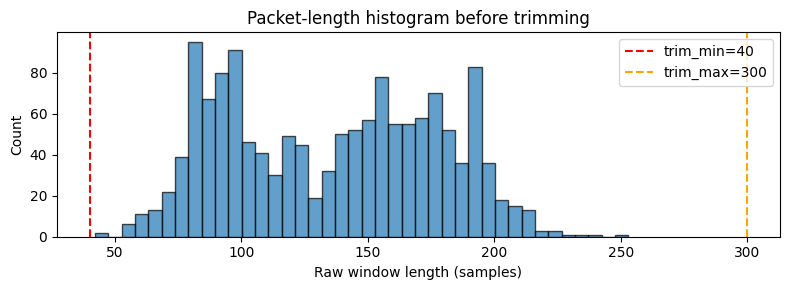

In [4]:
# Parse raw sources only if base CSV is absent.
# Supported source layouts:
# 1) Cached imudata.csv
# 2) Flat gesture txt logs in the active dataset folder -> auto-build imudata.csv
# 3) Class folders: <label>/*.txt where each file is [T,6]
# 4) Raw UCI HAR inertial files under "UCI HAR Dataset"
# 5) Legacy project txt logs separated by HEADER marker

# Old public/UCI labels are kept here for compatibility only.
UCI_LABEL_ORDER = [
    'WALKING',
    'WALKING_UPSTAIRS',
    'WALKING_DOWNSTAIRS',
    'SITTING',
    'STANDING',
    'LAYING',
]
UCI_CLASS_MAP = {name.lower(): idx for idx, name in enumerate(UCI_LABEL_ORDER)}
# Active project labels plus old aliases kept for backwards compatibility.
LEGACY_CLASS_MAP = dict(CLASS_MAP)


def normalize_label_token(name: str) -> str:
    return name.strip().lower().replace(' ', '_').replace('-', '_')


# Robust text decoding for legacy logger exports.
def read_log_lines(file_path: Path):
    raw = file_path.read_bytes()
    text = None
    for enc in ('utf-8-sig', 'utf-8', 'utf-16'):
        try:
            text = raw.decode(enc)
            break
        except UnicodeDecodeError:
            pass
    if text is None:
        text = raw.decode('utf-8', errors='ignore')
    return text.replace('\x00', '').splitlines()


# Parse one CSV-like IMU row into 6 float channels; return None for headers/noise lines.
def parse_sensor_row(line: str):
    line = line.strip()
    if not line or line.startswith('---'):
        return None
    parts = [p.strip() for p in line.split(',')]
    if len(parts) != 6:
        return None
    try:
        return [float(p) for p in parts]
    except ValueError:
        return None


# Split each legacy txt file into recording blocks using the marker line as boundary.
def extract_recordings(file_path: Path):
    lines = read_log_lines(file_path)
    blocks, cur = [], []
    in_data = False
    for raw_line in lines:
        line = raw_line.strip()
        if HEADER_MARKER in line:
            if cur:
                blocks.append(np.asarray(cur, dtype=np.float32))
                cur = []
            in_data = True
            continue
        if not in_data:
            continue
        parsed = parse_sensor_row(line)
        if parsed is not None:
            cur.append(parsed)
    if cur:
        blocks.append(np.asarray(cur, dtype=np.float32))
    return blocks


def _try_load_window_txt(path: Path):
    """Load one sample text file as [T,6], accepting comma or whitespace delimiters."""
    arr = None
    for delim in (',', None):
        try:
            arr = np.loadtxt(path, dtype=np.float32, delimiter=delim)
            break
        except Exception:
            arr = None
    if arr is None:
        return None
    if arr.ndim == 1:
        if arr.size % NUM_AXES != 0:
            return None
        arr = arr.reshape(-1, NUM_AXES)
    if arr.ndim != 2 or arr.shape[1] != NUM_AXES:
        return None
    if np.isnan(arr).any():
        return None
    return arr.astype(np.float32)


def discover_class_dirs(root: Path):
    """Return directories that directly contain sample .txt files."""
    class_dirs = []
    for d in sorted(root.iterdir()):
        if not d.is_dir():
            continue
        txt_files = sorted(d.glob('*.txt'))
        if txt_files:
            class_dirs.append((d, txt_files))
    return class_dirs


def build_folder_class_map(class_dirs):
    """Choose stable class-id mapping based on discovered folder names."""
    norm_names = [normalize_label_token(d.name) for d, _ in class_dirs]
    uniq = set(norm_names)

    if uniq and uniq.issubset(set(UCI_CLASS_MAP.keys())):
        folder_to_id = {d: UCI_CLASS_MAP[normalize_label_token(d.name)] for d, _ in class_dirs}
    elif uniq and uniq.issubset(set(LEGACY_CLASS_MAP.keys())):
        folder_to_id = {d: LEGACY_CLASS_MAP[normalize_label_token(d.name)] for d, _ in class_dirs}
    else:
        ordered = sorted(uniq)
        dynamic = {name: idx for idx, name in enumerate(ordered)}
        folder_to_id = {d: dynamic[normalize_label_token(d.name)] for d, _ in class_dirs}

    id_to_label = {}
    for d, _ in class_dirs:
        label_id = folder_to_id[d]
        norm = normalize_label_token(d.name)
        if norm in LEGACY_CLASS_MAP:
            label_name = PROJECT_LABEL_ORDER[LEGACY_CLASS_MAP[norm]]
        elif norm in UCI_CLASS_MAP:
            label_name = UCI_LABEL_ORDER[UCI_CLASS_MAP[norm]]
        else:
            label_name = d.name
        id_to_label[label_id] = label_name
    return folder_to_id, id_to_label


# Convert class-folder samples into canonical table keyed by measurement_id / sequence_id.
def parse_class_folders_to_imudata(root: Path, out_csv: Path):
    class_dirs = discover_class_dirs(root)
    if not class_dirs:
        raise RuntimeError('No class folders with txt files found.')

    folder_to_id, _ = build_folder_class_map(class_dirs)
    rows = []
    m_id = 0

    for d, txt_files in class_dirs:
        lbl_id = folder_to_id[d]
        norm = normalize_label_token(d.name)
        lbl_name = PROJECT_LABEL_ORDER[lbl_id] if norm in LEGACY_CLASS_MAP else d.name
        for fp in txt_files:
            sample = _try_load_window_txt(fp)
            if sample is None or len(sample) < 10:
                continue
            for t, vec in enumerate(sample):
                rows.append({
                    'measurement_id': m_id,
                    'sequence_id': t,
                    'label_id': int(lbl_id),
                    'label': lbl_name,
                    'gyro_x': float(vec[0]), 'gyro_y': float(vec[1]), 'gyro_z': float(vec[2]),
                    'acc_x': float(vec[3]), 'acc_y': float(vec[4]), 'acc_z': float(vec[5]),
                })
            m_id += 1

    if not rows:
        raise RuntimeError('Class folders found but no valid samples were parsed.')

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df


def find_uci_har_root(search_root: Path):
    for p in search_root.rglob('UCI HAR Dataset'):
        if not p.is_dir():
            continue
        if '__MACOSX' in str(p):
            continue
        if (p / 'train' / 'Inertial Signals').exists() and (p / 'test' / 'Inertial Signals').exists():
            return p
    return None


# Parse raw UCI HAR inertial files into canonical row-wise schema.
def parse_uci_har_to_imudata(uci_root: Path, out_csv: Path):
    label_id_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
    label_name_map = {
        1: 'WALKING',
        2: 'WALKING_UPSTAIRS',
        3: 'WALKING_DOWNSTAIRS',
        4: 'SITTING',
        5: 'STANDING',
        6: 'LAYING',
    }

    rows = []
    m_id = 0

    for split in ('train', 'test'):
        y = np.loadtxt(uci_root / split / f'y_{split}.txt', dtype=np.int64)
        sig_dir = uci_root / split / 'Inertial Signals'

        gx = np.loadtxt(sig_dir / f'body_gyro_x_{split}.txt', dtype=np.float32)
        gy = np.loadtxt(sig_dir / f'body_gyro_y_{split}.txt', dtype=np.float32)
        gz = np.loadtxt(sig_dir / f'body_gyro_z_{split}.txt', dtype=np.float32)
        ax = np.loadtxt(sig_dir / f'body_acc_x_{split}.txt', dtype=np.float32)
        ay = np.loadtxt(sig_dir / f'body_acc_y_{split}.txt', dtype=np.float32)
        az = np.loadtxt(sig_dir / f'body_acc_z_{split}.txt', dtype=np.float32)

        n = len(y)
        for arr in (gx, gy, gz, ax, ay, az):
            if arr.shape != (n, 128):
                raise ValueError(f'Unexpected UCI shape in {split}: {arr.shape}, expected {(n, 128)}')

        for i in range(n):
            raw_label = int(y[i])
            if raw_label not in label_id_map:
                continue

            lbl_id = label_id_map[raw_label]
            lbl_name = label_name_map[raw_label]
            sample = np.stack([gx[i], gy[i], gz[i], ax[i], ay[i], az[i]], axis=1)  # [128,6]

            for t, vec in enumerate(sample):
                rows.append({
                    'measurement_id': m_id,
                    'sequence_id': t,
                    'label_id': int(lbl_id),
                    'label': lbl_name,
                    'gyro_x': float(vec[0]), 'gyro_y': float(vec[1]), 'gyro_z': float(vec[2]),
                    'acc_x': float(vec[3]), 'acc_y': float(vec[4]), 'acc_z': float(vec[5]),
                })
            m_id += 1

    if not rows:
        raise RuntimeError('UCI HAR source found but no rows parsed.')

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df


# Legacy flat txt parser for older project logs.
def parse_legacy_txt_to_imudata(txt_dir: Path, out_csv: Path):
    rows = []
    m_id = 0
    for fp in sorted(txt_dir.glob('*.txt')):
        lbl = normalize_label_token(fp.stem)
        if lbl not in LEGACY_CLASS_MAP:
            continue
        lbl_id = LEGACY_CLASS_MAP[lbl]
        lbl_name = PROJECT_LABEL_ORDER[lbl_id]
        for block in extract_recordings(fp):
            if len(block) < 10:
                continue
            for t, sample in enumerate(block):
                rows.append({
                    'measurement_id': m_id,
                    'sequence_id': t,
                    'label_id': lbl_id,
                    'label': lbl_name,
                    'gyro_x': float(sample[0]), 'gyro_y': float(sample[1]), 'gyro_z': float(sample[2]),
                    'acc_x': float(sample[3]), 'acc_y': float(sample[4]), 'acc_z': float(sample[5]),
                })
            m_id += 1

    if not rows:
        raise RuntimeError('No valid recordings from legacy txt files.')

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df


def _find_gesture_csv_builder() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        candidate = root / 'tools' / 'build_gesture_imudata_csv.py'
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not find tools/build_gesture_imudata_csv.py from cwd={cwd}')


def build_imudata_csv_from_txt(txt_dir: Path, out_csv: Path) -> pd.DataFrame:
    import subprocess
    import sys

    builder = _find_gesture_csv_builder()
    cmd = [
        sys.executable,
        str(builder),
        '--input-dir', str(txt_dir),
        '--output-csv', str(out_csv),
        '--overwrite',
    ]
    print('Base CSV missing; building imudata.csv from txt logs...')
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
    return pd.read_csv(out_csv)


# Load cached base CSV when available; otherwise auto-detect source and build it.
def load_base_df() -> pd.DataFrame:
    if IMUDATA_CSV.exists():
        print('Loading cached base CSV:', IMUDATA_CSV)
        return pd.read_csv(IMUDATA_CSV)

    flat_txt = sorted(GESTURE_DIR.glob('*.txt'))
    if flat_txt:
        return build_imudata_csv_from_txt(GESTURE_DIR, IMUDATA_CSV)

    class_dirs = discover_class_dirs(GESTURE_DIR)
    if class_dirs:
        print('Base CSV missing; parsing class-folder txt samples...')
        return parse_class_folders_to_imudata(GESTURE_DIR, IMUDATA_CSV)

    uci_root = find_uci_har_root(GESTURE_DIR)
    if uci_root is not None:
        print('Base CSV missing; parsing raw UCI HAR inertial files...')
        return parse_uci_har_to_imudata(uci_root, IMUDATA_CSV)

    raise RuntimeError('No usable base source found (imudata.csv, txt logs, class folders, UCI HAR, or legacy txt).')


def build_base_windows(df: pd.DataFrame):
    """Trim → filter → baseline-remove → FFT-resample each measurement to [WINDOW_SIZE, 6].

    Pipeline matches ultra96/deployment/imu.py exactly:
    1. Reject raw windows longer than RAW_MAX_LEN.
    2. Motion-based trim (gyro magnitude threshold).
    3. Reject if trimmed length outside [TRIM_MIN, TRIM_MAX].
    4. Baseline removal (subtract mean of first BASELINE_FRAMES).
    5. FFT-resample to WINDOW_SIZE.
    """
    req = {'measurement_id', 'sequence_id', 'label_id', *SENSOR_COLUMNS}
    if req.difference(df.columns):
        raise ValueError(f'Missing columns: {sorted(req.difference(df.columns))}')

    df = df.copy()
    df['sequence_id'] = pd.to_numeric(df['sequence_id'], errors='coerce')

    id_to_label = {}
    if 'label' in df.columns:
        tmp = df[['label_id', 'label']].dropna().drop_duplicates()
        tmp['label_id'] = pd.to_numeric(tmp['label_id'], errors='coerce')
        tmp = tmp.dropna().sort_values('label_id')
        id_to_label = {int(r.label_id): str(r.label) for r in tmp.itertuples(index=False)}

    X_list, y_list = [], []
    drop_reasons = {'mixed_label': 0, 'bad_seq': 0, 'too_short': 0, 'too_long_raw': 0,
                    'trim_too_short': 0, 'trim_too_long': 0}
    raw_lengths = []  # For histogram logging.

    for _, g in df.groupby('measurement_id', sort=False):
        g = g.sort_values('sequence_id', kind='mergesort')

        if g['label_id'].nunique() != 1:
            drop_reasons['mixed_label'] += 1
            continue
        if g['sequence_id'].isna().any():
            drop_reasons['bad_seq'] += 1
            continue

        raw = g[SENSOR_COLUMNS].to_numpy(dtype=np.float32)
        raw_len = len(raw)
        raw_lengths.append(raw_len)

        if raw_len < 10:
            drop_reasons['too_short'] += 1
            continue
        if raw_len > RAW_MAX_LEN:
            drop_reasons['too_long_raw'] += 1
            continue

        # 1. Motion-based trim
        trimmed = trim_idle(raw)
        trimmed_len = len(trimmed)

        if trimmed_len < TRIM_MIN:
            drop_reasons['trim_too_short'] += 1
            continue
        if trimmed_len > TRIM_MAX:
            drop_reasons['trim_too_long'] += 1
            continue

        # 2. Baseline removal
        trimmed = remove_baseline(trimmed)

        # 3. FFT resample to target length
        resampled = fft_resample_window(trimmed, WINDOW_SIZE)

        X_list.append(resampled)
        y_list.append(int(g.iloc[0]['label_id']))

    if not X_list:
        raise RuntimeError('No valid windows after filter step.')

    X = np.stack(X_list, axis=0)  # [N, WINDOW_SIZE, 6]
    y = np.asarray(y_list, dtype=np.int64)
    dropped_total = sum(drop_reasons.values())
    return X, y, id_to_label, dropped_total, drop_reasons, raw_lengths


def save_windows_csv(X, y, out_csv, id_to_label):
    rows = []
    for mid in range(len(X)):
        lbl = int(y[mid])
        lbl_name = id_to_label.get(lbl, str(lbl))
        for t in range(WINDOW_SIZE):
            rows.append({
                'measurement_id': mid,
                'sequence_id': t,
                'label_id': lbl,
                'label': lbl_name,
                'gyro_x': float(X[mid, t, 0]), 'gyro_y': float(X[mid, t, 1]), 'gyro_z': float(X[mid, t, 2]),
                'acc_x': float(X[mid, t, 3]), 'acc_y': float(X[mid, t, 4]), 'acc_z': float(X[mid, t, 5]),
            })
    pd.DataFrame(rows).to_csv(out_csv, index=False)


df_base = load_base_df().copy()
if 'source' not in df_base.columns:
    df_base['source'] = GESTURE_DIR.name
if 'path' not in df_base.columns:
    df_base['path'] = str(IMUDATA_CSV)

merge_manifest = {
    'base_measurements': int(df_base['measurement_id'].nunique()),
    'base_rows': int(len(df_base)),
    'dashboard_sources': [str(path) for path in DASHBOARD_GESTURE_SOURCES],
}

if INCLUDE_DASHBOARD_GESTURE_DATA and DASHBOARD_GESTURE_SOURCES:
    dashboard_start_id = int(pd.to_numeric(df_base['measurement_id'], errors='coerce').max()) + 1
    dashboard_df = build_dashboard_gesture_dataframe(
        DASHBOARD_GESTURE_SOURCES,
        measurement_id_start=dashboard_start_id,
    )
    if not dashboard_df.empty:
        shared_columns = list(dict.fromkeys([*df_base.columns.tolist(), *dashboard_df.columns.tolist()]))
        df_base = pd.concat(
            [df_base.reindex(columns=shared_columns), dashboard_df.reindex(columns=shared_columns)],
            ignore_index=True,
        )
        df_base.to_csv(GESTURE_COMBINED_CSV, index=False)
        merge_manifest['dashboard_measurements'] = int(dashboard_df['measurement_id'].nunique())
        merge_manifest['dashboard_rows'] = int(len(dashboard_df))
        merge_manifest['dashboard_class_counts'] = dashboard_df['label'].value_counts().sort_index().to_dict()
        merge_manifest['combined_measurements'] = int(df_base['measurement_id'].nunique())
        merge_manifest['combined_rows'] = int(len(df_base))
        print('Merged dashboard gesture samples into training base:', GESTURE_COMBINED_CSV)
    else:
        merge_manifest['dashboard_measurements'] = 0
        merge_manifest['dashboard_rows'] = 0
        print('Dashboard gesture roots found, but no valid reviewed samples were parsed.')
else:
    merge_manifest['dashboard_measurements'] = 0
    merge_manifest['dashboard_rows'] = 0

with open(GESTURE_MERGE_MANIFEST_JSON, 'w') as f:
    _json.dump(merge_manifest, f, indent=2)
print('Saved gesture merge manifest:', GESTURE_MERGE_MANIFEST_JSON)
print('Base source counts:', df_base['source'].value_counts().sort_index().to_dict())

X_base, y_base, id_to_label, dropped, drop_reasons, raw_lengths = build_base_windows(df_base)
ACTIVE_LABELS = [id_to_label.get(i, str(i)) for i in sorted(np.unique(y_base).tolist())]
print('X_base:', X_base.shape, 'y_base:', y_base.shape, 'total dropped:', dropped)
print('Drop reasons:', drop_reasons)
print('Class counts:', {int(i): int((y_base == i).sum()) for i in np.unique(y_base)})
print('Active labels:', ACTIVE_LABELS)

# Raw window length histogram
print(f'\nRaw window lengths: min={min(raw_lengths)}, max={max(raw_lengths)}, '
      f'median={int(np.median(raw_lengths))}, mean={np.mean(raw_lengths):.1f}')
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.hist(raw_lengths, bins=40, edgecolor='black', alpha=0.7)
ax.set_xlabel('Raw window length (samples)')
ax.set_ylabel('Count')
ax.set_title('Packet-length histogram before trimming')
ax.axvline(TRIM_MIN, color='red', linestyle='--', label=f'trim_min={TRIM_MIN}')
ax.axvline(TRIM_MAX, color='orange', linestyle='--', label=f'trim_max={TRIM_MAX}')
ax.legend()
plt.tight_layout()
plt.show()


## 2) Split first, then augment train only


In [5]:
# Split at base-sample level before any train augmentation.
idx = np.arange(len(X_base))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_base,
)
train_idx_inner, val_idx = train_test_split(
    train_idx,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_base[train_idx],
)

X_train_seed = X_base[train_idx_inner].astype(np.float32)
y_train_seed = y_base[train_idx_inner].astype(np.int64)
X_val_raw = X_base[val_idx].astype(np.float32)
y_val = y_base[val_idx].astype(np.int64)
X_test_raw = X_base[test_idx].astype(np.float32)
y_test = y_base[test_idx].astype(np.int64)


def augment_window_np(x):
    """Augment a single [WINDOW_SIZE, 6] window with mild, realistic perturbations.

    Changes from previous version:
    - Reduced global channel shift from U(-0.1, 0.1) to U(-0.02, 0.02) to avoid
      unrealistic offsets that don't reflect real sensor behaviour.
    - Jitter std kept at 0.05 (mild).
    - Scaling range kept at [0.8, 1.2] (mild).
    - Time-warp via crop+resample uses fft_resample_window (matching deployment).
    """
    z = x.copy()
    # Additive jitter (simulates sensor noise)
    z += np.random.normal(0.0, 0.05, size=z.shape).astype(np.float32)
    # Global scaling (simulates different gesture intensities)
    z *= np.float32(np.random.uniform(0.8, 1.2))
    # Small per-channel shift (simulates minor calibration drift — kept small)
    z += np.random.uniform(-0.02, 0.02, size=(1, 6)).astype(np.float32)

    # Optional crop + resample to mimic time-warp style variation
    if np.random.rand() < 0.4:
        n = len(z)
        left = np.random.randint(0, max(1, int(n * 0.1)))
        right = n - np.random.randint(0, max(1, int(n * 0.1)))
        right = max(right, left + 10)
        z = fft_resample_window(z[left:right], WINDOW_SIZE)

    return z


def augment_train_set(X_seed, y_seed, factor):
    # 1 -> factor mapping (includes original copy)
    feats = [X_seed.astype(np.float32)]
    labels = [y_seed.astype(np.int64)]
    for _ in range(max(factor - 1, 0)):
        aug = np.stack([augment_window_np(w) for w in X_seed], axis=0)
        feats.append(aug)
        labels.append(y_seed.astype(np.int64))
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)


X_train_raw, y_train = augment_train_set(X_train_seed, y_train_seed, AUGMENT_FACTOR)
save_windows_csv(X_train_raw, y_train, TRAIN_CSV_OUT, id_to_label)
save_windows_csv(X_val_raw, y_val, VAL_CSV_OUT, id_to_label)
save_windows_csv(X_test_raw, y_test, TEST_CSV_OUT, id_to_label)
split_summary = {
    'train_seed_count': int(len(X_train_seed)),
    'train_augmented_count': int(len(X_train_raw)),
    'val_count': int(len(X_val_raw)),
    'test_count': int(len(X_test_raw)),
    'train_class_counts': {id_to_label.get(int(c), str(int(c))): int((y_train == c).sum()) for c in np.unique(y_train)},
    'val_class_counts': {id_to_label.get(int(c), str(int(c))): int((y_val == c).sum()) for c in np.unique(y_val)},
    'test_class_counts': {id_to_label.get(int(c), str(int(c))): int((y_test == c).sum()) for c in np.unique(y_test)},
}
with open(GESTURE_SPLIT_SUMMARY_JSON, 'w') as f:
    _json.dump(split_summary, f, indent=2)
print('Saved split CSVs:', TRAIN_CSV_OUT, VAL_CSV_OUT, TEST_CSV_OUT)
print('Saved split summary:', GESTURE_SPLIT_SUMMARY_JSON)

print('Seed split:', X_train_seed.shape, X_val_raw.shape, X_test_raw.shape)
print('Train after augmentation:', X_train_raw.shape)

# Check class balance after all filtering + augmentation
print('\nPost-augmentation class counts (train):')
for c in sorted(np.unique(y_train)):
    print(f'  {id_to_label.get(int(c), c)}: {int((y_train == c).sum())}')
print('Val class counts:')
for c in sorted(np.unique(y_val)):
    print(f'  {id_to_label.get(int(c), c)}: {int((y_val == c).sum())}')
print('Test class counts:')
for c in sorted(np.unique(y_test)):
    print(f'  {id_to_label.get(int(c), c)}: {int((y_test == c).sum())}')

Saved split CSVs: ../data/gesture/20260411/imudata_trai_augmented.csv ../data/gesture/20260411/imudata_val.csv ../data/gesture/20260411/imudata_test.csv
Saved split summary: ../data/gesture/20260411/split_summary.json
Seed split: (1026, 60, 6) (114, 60, 6) (286, 60, 6)
Train after augmentation: (3078, 60, 6)

Post-augmentation class counts (train):
  Raise: 528
  Shake: 522
  Chop: 528
  Stir: 501
  Swing: 498
  Punch: 501
Val class counts:
  Raise: 19
  Shake: 19
  Chop: 20
  Stir: 18
  Swing: 19
  Punch: 19
Test class counts:
  Raise: 49
  Shake: 49
  Chop: 49
  Stir: 46
  Swing: 47
  Punch: 46


## 3) Normalise from train only -> DataLoaders


In [6]:
# Fit scaler on train only to avoid leakage
scaler = StandardScaler()
X_train_flat = X_train_raw.reshape(-1, NUM_AXES)
X_val_flat = X_val_raw.reshape(-1, NUM_AXES)
X_test_flat = X_test_raw.reshape(-1, NUM_AXES)

scaler.fit(X_train_flat)
X_train_scaled = scaler.transform(X_train_flat).reshape(-1, WINDOW_SIZE, NUM_AXES)
X_val_scaled = scaler.transform(X_val_flat).reshape(-1, WINDOW_SIZE, NUM_AXES)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, WINDOW_SIZE, NUM_AXES)

np.save(MEAN_NPY, scaler.mean_.astype(np.float32))
np.save(STD_NPY, scaler.scale_.astype(np.float32))
print('Saved mean/std:', MEAN_NPY, STD_NPY)

# ── Save preprocessing metadata alongside the model ──
preprocess_meta = {
    "feature_order": SENSOR_COLUMNS,
    "deployment_feature_order": ["gx", "gy", "gz", "ax", "ay", "az"],
    "window_size": WINDOW_SIZE,
    "num_axes": NUM_AXES,
    "resample_method": RESAMPLE_METHOD,
    "gyro_idle_threshold": GYRO_IDLE_THRESHOLD,
    "trim_min": TRIM_MIN,
    "trim_max": TRIM_MAX,
    "raw_max_len": RAW_MAX_LEN,
    "baseline_frames": BASELINE_FRAMES,
    "mean": scaler.mean_.tolist(),
    "std": scaler.scale_.tolist(),
    "num_classes": NUM_CLASSES,
    "label_order": PROJECT_LABEL_ORDER,
    "augment_factor": AUGMENT_FACTOR,
}
with open(PREPROCESS_META_JSON, 'w') as f:
    _json.dump(preprocess_meta, f, indent=2)
print('Saved preprocessing metadata:', PREPROCESS_META_JSON)

# Conv1d expects [N,C,T]. HLS/local board tests also consume the z-scored tensor because
# gesture hardware now uses software normalisation rather than fused raw-input weights.
X_train = np.transpose(X_train_scaled, (0, 2, 1)).astype(np.float32)
X_val = np.transpose(X_val_scaled, (0, 2, 1)).astype(np.float32)
X_test = np.transpose(X_test_scaled, (0, 2, 1)).astype(np.float32)

np.save(GESTURE_TEST_X_NPY, X_test.astype(np.float32))
np.save(GESTURE_TEST_X_RAW_NPY, X_test_raw.astype(np.float32))
np.save(GESTURE_TEST_Y_NPY, y_test.astype(np.int64))
print('Saved gesture test arrays:')
print('  norm:', GESTURE_TEST_X_NPY)
print('  raw :', GESTURE_TEST_X_RAW_NPY)
print('  y   :', GESTURE_TEST_Y_NPY)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print('Data ready:', X_train.shape, X_val.shape, X_test.shape)

Saved mean/std: ../data/gesture/20260411/mean.npy ../data/gesture/20260411/std.npy
Saved preprocessing metadata: ../data/gesture/20260411/preprocess_meta.json
Saved gesture test arrays:
  norm: ../data/gesture/20260411/gesture_X_test.npy
  raw : ../data/gesture/20260411/gesture_X_test_raw.npy
  y   : ../data/gesture/20260411/gesture_y_test.npy
Data ready: (3078, 6, 60) (114, 6, 60) (286, 6, 60)


## 4) Model, training, evaluation


Model summary (Keras-style):
Layer (type)       Output Shape        Param #
Conv1d             (1, 16, 60)        304
ReLU               (1, 16, 60)        0
MaxPool1d          (1, 16, 30)        0
Conv1d             (1, 32, 30)        1,568
ReLU               (1, 32, 30)        0
MaxPool1d          (1, 32, 15)        0
Linear             (1, 32)            15,392
ReLU               (1, 32)            0
Linear             (1, 6)             198
Total params: 17,462
Trainable params: 17,462
Non-trainable params: 0
Start training for 60 epochs...
Epoch 1/60 | Loss 0.5178 | Train 87.20% | Val 97.37% | LR 0.001000
Epoch 5/60 | Loss 0.0088 | Train 99.94% | Val 99.12% | LR 0.001000
Epoch 10/60 | Loss 0.0011 | Train 100.00% | Val 100.00% | LR 0.000500
Early stop at epoch 13 (best val 100.00%)
Best val acc: 100.00%
Final Test Accuracy (float): 98.25%
Final Test Accuracy (Q8.8-sim): 98.25%


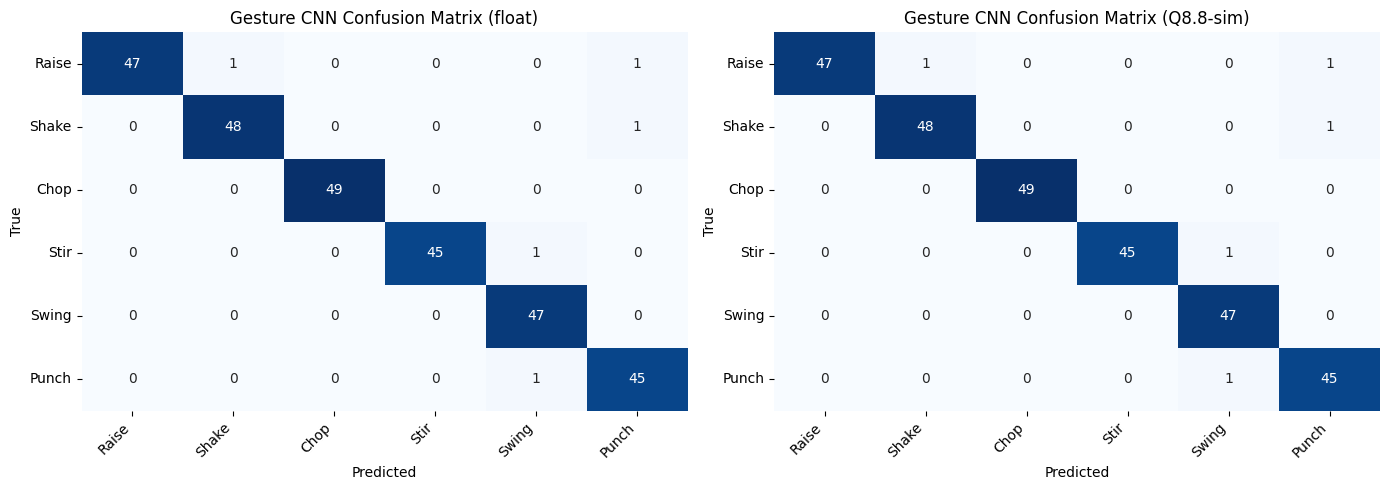

In [7]:
# Model input to forward(): [B, 6, 60] (channels-first for Conv1d).
class GestureCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(6, 16, kernel_size=3, padding=1)
        # Shape: [B, 6, 60] -> [B, 16, 60] (padding keeps temporal length).
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        # Shape after pool1: [B, 16, 60] -> [B, 16, 30].

        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        # Shape: [B, 16, 30] -> [B, 32, 30].
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        # Shape after pool2: [B, 32, 30] -> [B, 32, 15].

        self.flat = 32 * 15
        # Flatten length = 32 channels * 15 timesteps = 480 features.
        self.fc1 = nn.Linear(self.flat, 32)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(32, NUM_CLASSES)

    def forward(self, x):
        # Convolution blocks extract local temporal patterns before FC classification.
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, self.flat)
        x = self.relu3(self.fc1(x))
        return self.fc2(x)


def print_model_summary(model, sample_input):
    rows, hooks = [], []

    def hook_fn(module, inputs, outputs):
        out = outputs[0] if isinstance(outputs, (list, tuple)) else outputs
        out_shape = tuple(out.shape) if isinstance(out, torch.Tensor) else str(type(out))
        params = sum(p.numel() for p in module.parameters(recurse=False))
        rows.append((module.__class__.__name__, out_shape, params))

    for module in model.modules():
        if module is model or len(list(module.children())) > 0:
            continue
        hooks.append(module.register_forward_hook(hook_fn))

    was_training = model.training
    model.eval()
    with torch.no_grad():
        _ = model(sample_input)
    for hook in hooks:
        hook.remove()
    if was_training:
        model.train()

    print('Layer (type)       Output Shape        Param #')
    print('================================================')
    for name, shape, params in rows:
        print(f'{name:<18} {str(shape):<18} {params:,}')
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('================================================')
    print(f'Total params: {total_params:,}')
    print(f'Trainable params: {trainable_params:,}')
    print(f'Non-trainable params: {total_params - trainable_params:,}')


model = GestureCNN().to(device)
print('Model summary (Keras-style):')
print_model_summary(model, torch.zeros(1, 6, 60, device=device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)


def eval_acc(m, loader):
    m.eval()
    corr, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            pred = torch.argmax(m(xb), dim=1)
            corr += (pred == yb).sum().item()
            total += yb.size(0)
    return 100.0 * corr / max(total, 1)


# Standard train loop with validation-driven LR scheduling and early stopping.
best_val = -1.0
best_state = copy.deepcopy(model.state_dict())
pat = 0
print(f'Start training for {EPOCHS} epochs...')

for ep in range(EPOCHS):
    model.train()
    run_loss, corr, total = 0.0, 0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        run_loss += loss.item()
        pred = torch.argmax(out, dim=1)
        corr += (pred == yb).sum().item()
        total += yb.size(0)

    tr_acc = 100.0 * corr / max(total, 1)
    val_acc = eval_acc(model, val_loader)
    scheduler.step(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        best_state = copy.deepcopy(model.state_dict())
        pat = 0
    else:
        pat += 1

    if ep == 0 or (ep + 1) % 5 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {ep+1}/{EPOCHS} | Loss {run_loss/max(len(train_loader),1):.4f} | Train {tr_acc:.2f}% | Val {val_acc:.2f}% | LR {lr:.6f}')

    if pat >= EARLY_STOPPING_PATIENCE:
        print(f'Early stop at epoch {ep+1} (best val {best_val:.2f}%)')
        break

model.load_state_dict(best_state)
print(f'Best val acc: {best_val:.2f}%')


# Q8.8 simulation: quantize/dequantize inputs to estimate fixed-point impact before HLS export.
def q88_dequant(x):
    q = torch.round(torch.clamp(x, -128.0, 127.99609375) * 256.0)
    return q / 256.0


def eval_with_cm(m, loader, q88=False):
    m.eval()
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    corr, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xx = q88_dequant(xb) if q88 else xb
            pred = torch.argmax(m(xx), dim=1)
            corr += (pred == yb).sum().item()
            total += yb.size(0)
            yt = yb.detach().cpu().numpy()
            yp = pred.detach().cpu().numpy()
            for t, p in zip(yt, yp):
                cm[int(t), int(p)] += 1
    return 100.0 * corr / max(total, 1), cm


acc_float, cm_float = eval_with_cm(model, test_loader, q88=False)
acc_q88, cm_q88 = eval_with_cm(model, test_loader, q88=True)
print(f'Final Test Accuracy (float): {acc_float:.2f}%')
print(f'Final Test Accuracy (Q8.8-sim): {acc_q88:.2f}%')

labels = ACTIVE_LABELS if len(ACTIVE_LABELS) == NUM_CLASSES else [str(i) for i in range(NUM_CLASSES)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_float, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Gesture CNN Confusion Matrix (float)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_yticklabels(labels, rotation=0)

sns.heatmap(cm_q88, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Gesture CNN Confusion Matrix (Q8.8-sim)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


## 5) Export weights (fused normalisation)


In [13]:
def export_pytorch_weights(model, filename=None, fuse_input_norm=False, norm_mean=None, norm_std=None):
    # Export in C-header format expected by HLS C++ implementation.
    if model is None:
        raise ValueError('model is None; train/load model before export.')

    if filename is None:
        if 'WEIGHTS_H_PATH' in globals():
            filename = WEIGHTS_H_PATH
        elif 'GESTURE_DIR' in globals():
            filename = Path(GESTURE_DIR) / 'gesture_cnn_weights.h'
        else:
            filename = Path('gesture_cnn_weights.h')

    print(f'Exporting weights to {filename}...')
    params = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Optional: fuse (x-mean)/std into conv1. Gesture export keeps this disabled because the Q8.8
# hardware input cannot represent raw IMU magnitudes without heavy clipping.
    if fuse_input_norm:
        if norm_mean is None or norm_std is None:
            raise ValueError('norm_mean and norm_std are required when fuse_input_norm=True')

        w_key, b_key = 'conv1.weight', 'conv1.bias'
        if w_key not in params or b_key not in params:
            raise KeyError('conv1 weights/bias not found in model state_dict')

        mean_t = torch.as_tensor(norm_mean, dtype=params[w_key].dtype)
        std_t = torch.as_tensor(norm_std, dtype=params[w_key].dtype)

        if mean_t.numel() != params[w_key].shape[1] or std_t.numel() != params[w_key].shape[1]:
            raise ValueError('mean/std channel count mismatch')
        if torch.any(std_t == 0):
            raise ValueError('std contains zero; cannot fuse normalization')

        params[w_key] = params[w_key] * (1.0 / std_t).view(1, -1, 1)
        bias_shift = (params[w_key] * mean_t.view(1, -1, 1)).sum(dim=(1, 2))
        params[b_key] = params[b_key] - bias_shift
        print('Fused z-score normalization into conv1 for raw-input inference.')

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)

    with open(filename, 'w') as f:
        f.write('#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n')
        f.write('#include "gesture_typedefs.h"\n\n')

        # Emit one flattened array per PyTorch parameter tensor.
        total_params = 0
        for name, tensor in params.items():
            clean_name = name.replace('.', '_').replace('weight', 'w').replace('bias', 'b')
            data = tensor.numpy().flatten()
            total_params += len(data)

            f.write(f'// PyTorch Layer: {name} (Shape: {tuple(tensor.shape)})\n')
            f.write(f'static const data_t {clean_name}[{len(data)}] = {{\n')
            for i, val in enumerate(data):
                f.write(f'{val:.6f}')
                if i < len(data) - 1:
                    f.write(', ')
                if (i + 1) % 10 == 0:
                    f.write('\n    ')
            f.write('\n};\n\n')

        f.write('#endif // WEIGHTS_H\n')

    print(f'Done! Total parameters: {total_params}')



# Resolve normalization stats from the active run only.
if 'scaler' in globals() and hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
    export_mean = scaler.mean_
    export_std = scaler.scale_
    norm_source = 'in-memory scaler.mean_/scaler.scale_'
    mean_source = 'scaler.mean_'
    std_source = 'scaler.scale_'
elif Path(MEAN_NPY).exists() and Path(STD_NPY).exists():
    export_mean = np.load(MEAN_NPY)
    export_std = np.load(STD_NPY)
    norm_source = 'selected dataset npy files'
    mean_source = str(MEAN_NPY)
    std_source = str(STD_NPY)
else:
    raise RuntimeError(
        'Normalization stats for the selected gesture dataset are missing. '
        'Run the notebook from the active dataset path-selection cell downward.'
    )

print(f'Using normalization source: {norm_source}')
print(f'Using mean: {mean_source}')
print(f'Using std : {std_source}')
print(f'Normalization vector shapes -> mean: {np.asarray(export_mean).shape}, std: {np.asarray(export_std).shape}')

# Resolve output header path from the selected dataset.
out_weights = WEIGHTS_H_PATH if 'WEIGHTS_H_PATH' in globals() else (Path(GESTURE_DIR) / 'gesture_cnn_weights.h')

export_pytorch_weights(
    model=model,
    filename=out_weights,
    fuse_input_norm=False,
    norm_mean=export_mean,
    norm_std=export_std,
)

# Also export to HLS gesture folder (split layout), with fallback to legacy flat hls/ path.
repo_root = Path.cwd().resolve()
for p in [repo_root, *repo_root.parents]:
    if (p / 'hls').exists():
        repo_root = p
        break

hls_gesture_weights = repo_root / 'hls' / 'gesture' / 'gesture_cnn_weights.h'
if not hls_gesture_weights.parent.exists():
    hls_gesture_weights = repo_root / 'hls' / 'gesture_cnn_weights.h'

if Path(WEIGHTS_H_PATH).resolve() != hls_gesture_weights.resolve():
    export_pytorch_weights(
        model=model,
        filename=hls_gesture_weights,
        fuse_input_norm=False,
        norm_mean=export_mean,
        norm_std=export_std,
    )
else:
    print('HLS gesture weights path matches primary export; skipped duplicate export.')


Using normalization source: in-memory scaler.mean_/scaler.scale_
Using mean: scaler.mean_
Using std : scaler.scale_
Normalization vector shapes -> mean: (6,), std: (6,)
Exporting weights to ../data/gesture/20260411/gesture_cnn_weights.h...
Done! Total parameters: 17462
Exporting weights to /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/gesture/gesture_cnn_weights.h...
Done! Total parameters: 17462


In [14]:
# Generate HLS gesture testbench cases header from normalised gesture test arrays.
# Gesture hardware now expects z-scored IMU windows because raw preprocessed magnitudes clip badly
# in the Q8.8 AXIS input format.
import subprocess
import sys
from pathlib import Path


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'hls').exists():
            return p
    raise FileNotFoundError(f"Could not find hls/ from cwd={cwd}")


def _find_gesture_gen_script(repo_root: Path) -> Path:
    candidates = [
        repo_root / 'tools' / 'gen_gesture_tb_cases.py',
        repo_root / 'hls' / 'gesture' / 'gen_gesture_tb_cases.py',
        repo_root / 'hls' / 'gen_gesture_tb_cases.py',  # backward-compatible fallback
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Could not find gesture generator script under hls/.')


def _resolve_gesture_npy() -> tuple[Path, Path]:
    fx, fy = Path(GESTURE_TEST_X_NPY), Path(GESTURE_TEST_Y_NPY)
    if not fx.exists() or not fy.exists():
        raise FileNotFoundError(
            f'Selected gesture test arrays are missing: {fx} and {fy}. '
            'Run the notebook from the active dataset path-selection cell downward.'
        )
    return fx.resolve(), fy.resolve()


repo_root = _repo_root()
gen_script = _find_gesture_gen_script(repo_root)
features_npy, labels_npy = _resolve_gesture_npy()
out_h = (repo_root / 'hls' / 'gesture' / 'gesture_tb_cases.h').resolve()

tb_cases = int(globals().get('GESTURE_TB_NUM_CASES', 300))
tb_seed = int(globals().get('GESTURE_TB_SEED', 42))

cmd = [
    sys.executable,
    str(gen_script),
    '--features', str(features_npy),
    '--labels', str(labels_npy),
    '--out', str(out_h),
    '--num-cases', str(tb_cases),
    '--seed', str(tb_seed),
]

print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True, cwd=repo_root)
print('Generated:', out_h)


Running: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/.venv/bin/python /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/tools/gen_gesture_tb_cases.py --features /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/gesture/20260411/gesture_X_test.npy --labels /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/gesture/20260411/gesture_y_test.npy --out /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/gesture/gesture_tb_cases.h --num-cases 300 --seed 42
Wrote /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/gesture/gesture_tb_cases.h with 286 cases. Label distribution: 0:49, 1:49, 2:49, 3:46, 4:47, 5:46
Generated: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/gesture/gesture_tb_cases.h


In [10]:
# Sync normalised gesture test artefacts into ultra96/local-ai-test and gesture mean/std into deployment.
# The Ultra96/live board path now applies gesture normalisation in software before HLS.
import shutil
from pathlib import Path


def _repo_root_with_ultra96() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'ultra96').exists():
            return p
    raise FileNotFoundError(f"Could not find ultra96/ from cwd={cwd}")


def _resolve_gesture_test_npy() -> tuple[Path, Path, Path]:
    fx, fx_raw, fy = Path(GESTURE_TEST_X_NPY), Path(GESTURE_TEST_X_RAW_NPY), Path(GESTURE_TEST_Y_NPY)
    if not fx.exists() or not fx_raw.exists() or not fy.exists():
        raise FileNotFoundError(
            f'Selected gesture test arrays are missing: {fx}, {fx_raw}, and {fy}. '
            'Run the notebook from the active dataset path-selection cell downward.'
        )
    return fx.resolve(), fx_raw.resolve(), fy.resolve()


repo_root = _repo_root_with_ultra96()
features_npy, raw_features_npy, labels_npy = _resolve_gesture_test_npy()

ultra96_dir = Path(globals().get('ULTRA96_DIR', repo_root / 'ultra96' / 'local-ai-test')).resolve()
ultra96_dir.mkdir(parents=True, exist_ok=True)
ultra96_deploy_dir = (repo_root / 'ultra96' / 'deployment').resolve()
ultra96_deploy_dir.mkdir(parents=True, exist_ok=True)

dst_x = ultra96_dir / 'gesture_X_test.npy'
dst_x_raw = ultra96_dir / 'gesture_X_test_raw.npy'
dst_y = ultra96_dir / 'gesture_y_test.npy'
dst_mean = ultra96_deploy_dir / 'gesture_mean.npy'
dst_std = ultra96_deploy_dir / 'gesture_std.npy'

shutil.copy2(features_npy, dst_x)
shutil.copy2(raw_features_npy, dst_x_raw)
shutil.copy2(labels_npy, dst_y)
shutil.copy2(Path(MEAN_NPY), dst_mean)
shutil.copy2(Path(STD_NPY), dst_std)

print('Copied gesture test artefacts:')
print('  normalized:', features_npy, '->', dst_x)
print('  raw:', raw_features_npy, '->', dst_x_raw)
print('  labels:', labels_npy, '->', dst_y)
print('  mean:', Path(MEAN_NPY), '->', dst_mean)
print('  std:', Path(STD_NPY), '->', dst_std)


Copied gesture test artefacts:
  normalized: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/gesture/20260411/gesture_X_test.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/local-ai-test/gesture_X_test.npy
  raw: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/gesture/20260411/gesture_X_test_raw.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/local-ai-test/gesture_X_test_raw.npy
  labels: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/gesture/20260411/gesture_y_test.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/local-ai-test/gesture_y_test.npy
  mean: ../data/gesture/20260411/mean.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/deployment/gesture_mean.npy
  std: ../data/gesture/20260411/std.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/deployment/gesture_std.npy


In [11]:
# Prepare repo-local export bundles for Windows HLS and Ultra96 handoff.
import shutil
from pathlib import Path


def _repo_root_with_hls() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'hls').exists() and (p / 'ultra96').exists():
            return p
    raise FileNotFoundError(f"Could not find repo root with hls/ and ultra96/ from cwd={cwd}")


def _copy_files(files, dst_dir: Path) -> int:
    dst_dir.mkdir(parents=True, exist_ok=True)
    copied = 0
    for src in files:
        src_path = Path(src)
        if not src_path.exists() or not src_path.is_file():
            continue
        shutil.copy2(src_path, dst_dir / src_path.name)
        copied += 1
    return copied


repo_root = _repo_root_with_hls()
export_root = Path(globals().get('EXPORT_ROOT', repo_root / 'exports')).resolve()
hls_gesture_dir = repo_root / 'hls' / 'gesture'
ultra96_root = repo_root / 'ultra96'

gesture_hls_export_dir = export_root / 'windows_hls' / 'gesture'
ultra96_export_root = export_root / 'ultra96_runtime'
ultra96_local_export_dir = ultra96_export_root / 'ultra96' / 'local-ai-test'
ultra96_deploy_export_dir = ultra96_export_root / 'ultra96' / 'deployment'
ultra96_mqtt_export_dir = ultra96_export_root / 'ultra96' / 'mqtt-test'

gesture_hls_files = [
    p for p in sorted(hls_gesture_dir.iterdir())
    if p.is_file() and not (p.name.startswith('gen_') and p.suffix == '.py')
]
gesture_local_files = [
    ultra96_root / 'local-ai-test' / 'dual_cnn_test.py',
    ultra96_root / 'local-ai-test' / 'run_assessment_suite.py',
    ultra96_root / 'local-ai-test' / 'gesture_X_test.npy',
    ultra96_root / 'local-ai-test' / 'gesture_y_test.npy',
    ultra96_root / 'local-ai-test' / 'gesture_X_test_raw.npy',
]
gesture_deploy_files = [
    ultra96_root / 'deployment' / 'audio.py',
    ultra96_root / 'deployment' / 'common.py',
    ultra96_root / 'deployment' / 'deployment.py',
    ultra96_root / 'deployment' / 'hardware.py',
    ultra96_root / 'deployment' / 'imu.py',
    ultra96_root / 'deployment' / 'messages.py',
    ultra96_root / 'deployment' / 'mqtt_ai_bridge.py',
    ultra96_root / 'deployment' / 'reconstruct.py',
    ultra96_root / 'deployment' / 'runtime.py',
    ultra96_root / 'deployment' / 'gesture_mean.npy',
    ultra96_root / 'deployment' / 'gesture_std.npy',
]
gesture_mqtt_files = [
    ultra96_root / 'mqtt-test' / 'common.py',
    ultra96_root / 'mqtt-test' / 'self_test.py',
]

summary = {
    'gesture_hls_files': _copy_files(gesture_hls_files, gesture_hls_export_dir),
    'gesture_local_files': _copy_files(gesture_local_files, ultra96_local_export_dir),
    'gesture_deploy_files': _copy_files(gesture_deploy_files, ultra96_deploy_export_dir),
    'gesture_mqtt_files': _copy_files(gesture_mqtt_files, ultra96_mqtt_export_dir),
}

print('Prepared repo-local gesture export bundle:')
print('  HLS export:', gesture_hls_export_dir)
print('  Ultra96 export root:', ultra96_export_root)
for key, value in summary.items():
    print(f'  {key}: {value}')
print('Copy dual_cnn.xsa manually into the deployment and local-ai-test folders on the target machine.')


Prepared repo-local gesture export bundle:
  HLS export: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/exports/windows_hls/gesture
  Ultra96 export root: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/exports/ultra96_runtime
  gesture_hls_files: 6
  gesture_local_files: 5
  gesture_deploy_files: 11
  gesture_mqtt_files: 2
Copy dual_cnn.xsa manually into the deployment and local-ai-test folders on the target machine.
